<a href="https://colab.research.google.com/github/KandhimallaYashwanth/MajorProject/blob/DataCleaning/Copy_of_Major.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Drive Setup

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Project Folder Setup and Path Definitions

In [39]:
import os

PROJECT_DIR = '/content/drive/MyDrive/Heart_Disease_Project/'
DATA_DIR = os.path.join(PROJECT_DIR, 'Dataset/')
MODEL_DIR = os.path.join(PROJECT_DIR, 'Models/')
RESULTS_DIR = os.path.join(PROJECT_DIR, 'Results/')
NOTEBOOK_DIR = os.path.join(PROJECT_DIR, 'Notebooks/')

# Create directories if they don't exist
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(NOTEBOOK_DIR, exist_ok=True)

print(f"Project directory created: {PROJECT_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODEL_DIR}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Notebooks directory: {NOTEBOOK_DIR}")

Project directory created: /content/drive/MyDrive/Heart_Disease_Project/
Data directory: /content/drive/MyDrive/Heart_Disease_Project/Dataset/
Models directory: /content/drive/MyDrive/Heart_Disease_Project/Models/
Results directory: /content/drive/MyDrive/Heart_Disease_Project/Results/
Notebooks directory: /content/drive/MyDrive/Heart_Disease_Project/Notebooks/


# Adaptive Hybrid Quantum-Classical Neural Network for Early Heart Disease Diagnosis: Data Preprocessing

This notebook performs essential data cleaning, preprocessing, and exploratory data analysis (EDA) on the heart disease dataset (`heart.csv`). The processed data will be suitable for subsequent machine learning and quantum machine learning model development. This adheres to research best practices, ensuring data quality and reproducibility.

## Stage 1: Pre Processing

### 1.1 Project Setup and Reproducibility

#### 1.1 Import Required Libraries

In [40]:
# Standard scientific computing libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for preprocessing and model utilities
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# For saving the fitted scaler
import joblib

# For reproducibility: Set random seeds for consistent results across runs.
import random
random.seed(42)
np.random.seed(42)

# Configure plot style for professional-looking visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Required libraries imported successfully.")

Required libraries imported successfully.


### 1.2. Dataset Loading

In [41]:
import os

# Define the full path to heart.csv in Google Drive
heart_csv_path = os.path.join(DATA_DIR, 'heart.csv')

# Check if heart.csv exists in the specified Google Drive path
if not os.path.exists(heart_csv_path):
    print("heart.csv was not found in the Google Drive Dataset folder. Please upload heart.csv to MyDrive/Heart_Disease_Project/Dataset/.")
    # Initialize an empty DataFrame if the file is not found to prevent further errors
    df = pd.DataFrame()
else:
    try:
        df = pd.read_csv(heart_csv_path)
        print(f"Dataset '{heart_csv_path}' loaded successfully.")
    except Exception as e:
        print(f"Error loading heart.csv from Google Drive: {e}")
        df = pd.DataFrame()

# Display shape and first 5 rows as verification
if not df.empty:
    print(f"\n--- Dataset Shape ---: {df.shape} (rows, columns)")
    print("\n--- First 5 Rows ---")
    display(df.head())

Dataset '/content/drive/MyDrive/Heart_Disease_Project/Dataset/heart.csv' loaded successfully.

--- Dataset Shape ---: (1025, 14) (rows, columns)

--- First 5 Rows ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


### 1.3. Dataset Overview

In [42]:
# Display the first 5 rows to get a glimpse of the data structure and content.
print("\n--- First 5 Rows ---")
display(df.head())

# Display the last 5 rows to check for any anomalies at the end of the dataset.
print("\n--- Last 5 Rows ---")
display(df.tail())

# Display the shape of the dataset (number of rows, number of columns).
print(f"\n--- Dataset Shape ---: {df.shape} (rows, columns)")

# Display the column names to understand available features.
print("\n--- Column Names ---")
print(df.columns.tolist())

# Display data types of each column and check for non-null counts.
# This helps in identifying potential missing values and incorrect data types.
print("\n--- Data Types and Non-Null Counts ---")
df.info() # Changed from display(df.info()) as df.info() prints directly

# Display summary statistics for numerical columns.
# This provides insights into central tendency, dispersion, and shape of the distribution.
print("\n--- Summary Statistics (Numerical Columns) ---")
display(df.describe())


--- First 5 Rows ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0



--- Last 5 Rows ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0



--- Dataset Shape ---: (1025, 14) (rows, columns)

--- Column Names ---
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

--- Data Types and Non-Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
mem

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 1.4. Data Quality Analysis

####  1.4.1 Missing Values

In [43]:
# Check for missing values in each column.
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
# Filter to show only columns with missing values.
missing_values_display = missing_values[missing_values > 0]

if missing_values_display.empty:
    print("No missing values found in the dataset.")
else:
    print("Missing values found in the following columns:")
    display(missing_values_display)
    print("Note: Based on df.info(), all counts are non-null, so any missing values might be encoded as special values (e.g., 0 or -1).")


--- Missing Values ---
No missing values found in the dataset.


####  1.4.2  Duplicate Rows

In [44]:
# Check for duplicate rows across all columns.
print("\n--- Duplicate Rows ---")
duplicate_rows_count = df.duplicated().sum()

if duplicate_rows_count == 0:
    print("No duplicate rows found.")
else:
    print(f"Number of duplicate rows found: {duplicate_rows_count}")
    print("These duplicate rows will be removed in the next step to ensure data integrity.")


--- Duplicate Rows ---
Number of duplicate rows found: 723
These duplicate rows will be removed in the next step to ensure data integrity.


####  1.4.2 Invalid Values

In [45]:
# Check for invalid values or unexpected categories.
print("\n--- Checking for Invalid Values ---")

# Define categorical columns for explicit check. Numerical ranges are implicitly checked by df.describe().
# Based on common heart disease dataset understanding:
# 'sex': (0 = female, 1 = male)
# 'cp': chest pain type (0-3)
# 'fbs': fasting blood sugar > 120 mg/dl (0 = false, 1 = true)
# 'restecg': resting electrocardiographic results (0-2)
# 'exang': exercise induced angina (0 = no, 1 = yes)
# 'slope': the slope of the peak exercise ST segment (0-2)
# 'ca': number of major vessels (0-3) colored by flourosopy (often 0-4, with 4 potentially meaning 'missing' or 'unknown')
# 'thal': thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect, or sometimes 0,1,2,3 for different meanings)
# 'target': (0 = no disease, 1 = disease)
categorical_cols_expected_values = {
    'sex': [0, 1],
    'cp': [0, 1, 2, 3],
    'fbs': [0, 1],
    'restecg': [0, 1, 2],
    'exang': [0, 1],
    'slope': [0, 1, 2],
    'ca': [0, 1, 2, 3, 4], # Including 4 as some datasets use it for 'missing' or unknown, which is handled here as a valid category for now.
    'thal': [0, 1, 2, 3] # Some datasets use 0, 1, 2, 3, others 1, 2, 3. Checking for all.
}

# Keep track of invalid values found
invalid_values_found = False

for col, expected_vals in categorical_cols_expected_values.items():
    if col in df.columns:
        unique_vals = df[col].unique()
        # Check if all unique values are within the expected set
        unexpected_vals = [val for val in unique_vals if val not in expected_vals]
        if unexpected_vals:
            print(f"Warning: Column '{col}' contains unexpected values: {np.sort(unexpected_vals)}. Expected: {np.sort(expected_vals)}.")
            invalid_values_found = True
        else:
            print(f"Column '{col}' unique values {np.sort(unique_vals)} are within expected range.")
    else:
        print(f"Warning: Categorical column '{col}' not found in the dataset.")

if not invalid_values_found:
    print("All checked categorical features appear to have valid values.")
print("Numerical feature ranges have been visually inspected via `df.describe()` in Section 3.")


--- Checking for Invalid Values ---
Column 'sex' unique values [0 1] are within expected range.
Column 'cp' unique values [0 1 2 3] are within expected range.
Column 'fbs' unique values [0 1] are within expected range.
Column 'restecg' unique values [0 1 2] are within expected range.
Column 'exang' unique values [0 1] are within expected range.
Column 'slope' unique values [0 1 2] are within expected range.
Column 'ca' unique values [0 1 2 3 4] are within expected range.
Column 'thal' unique values [0 1 2 3] are within expected range.
All checked categorical features appear to have valid values.
Numerical feature ranges have been visually inspected via `df.describe()` in Section 3.


####  1.4.3 Target Class Distribution

In [46]:
# Check class distribution of the target variable ('target').
print("\n--- Class Distribution of Target Variable ---")
class_distribution = df['target'].value_counts()
print("Absolute counts:")
display(class_distribution)

# Calculate and print percentage distribution for quick assessment of balance.
class_percentage = df['target'].value_counts(normalize=True) * 100
print("\nPercentage distribution:")
display(class_percentage)

# Provide a warning if the dataset is highly imbalanced, which might require specific handling during modeling.
if class_percentage.min() < 20 or class_percentage.max() > 80: # Thresholds can be adjusted
    print("Observation: Potential class imbalance detected. This might require addressing during model training (e.g., using stratified sampling, oversampling, or undersampling techniques) to prevent biased models.")
else:
    print("Observation: Class distribution appears relatively balanced, which is good for model training.")


--- Class Distribution of Target Variable ---
Absolute counts:


,count
target,
1,526
0,499



Percentage distribution:


,proportion
target,
1,51.317073
0,48.682927


Observation: Class distribution appears relatively balanced, which is good for model training.


### 1.5. Data Cleaning

#### 1.5.1 Missing Value Verification After Duplicate Removal

In [47]:
# Re-check for missing values to ensure data integrity after modifications
print("\n--- Verification of Missing Values After Duplication Removal ---")
missing_values_after_dedup = df.isnull().sum()
print(missing_values_after_dedup[missing_values_after_dedup > 0])

if missing_values_after_dedup.sum() == 0:
    print("All missing values (if any) are confirmed to be absent from the dataset.")
else:
    print("Warning: Missing values still detected. Further investigation needed.")


--- Verification of Missing Values After Duplication Removal ---
Series([], dtype: int64)
All missing values (if any) are confirmed to be absent from the dataset.


#### 1.5.2 Save Cleaned Dataset

In [48]:
import os

# Store the initial number of rows before attempting to remove duplicates for summary purposes.
initial_rows_for_dedup = df.shape[0]

# Remove duplicate rows from the DataFrame. `inplace=True` modifies the DataFrame directly.
# Duplicates are identified based on all columns.
df.drop_duplicates(inplace=True)

# Get the number of rows after duplicate removal.
final_rows_after_dedup = df.shape[0]

duplicates_removed_count = initial_rows_for_dedup - final_rows_after_dedup

print(f"Number of rows before removing duplicates: {initial_rows_for_dedup}")
print(f"Number of rows after removing duplicates: {final_rows_after_dedup}")
print(f"Total duplicate rows removed: {duplicates_removed_count}")

if duplicates_removed_count > 0:
    print("Duplicate rows successfully removed.")
else:
    print("No new duplicate rows were found or removed (dataset might have been deduplicated already).")

# Save the cleaned (duplicate-free) dataset as 'cleaned_heart.csv' to Google Drive.
cleaned_heart_csv_path = os.path.join(DATA_DIR, 'cleaned_heart.csv')
df.to_csv(cleaned_heart_csv_path, index=False)
print(f"\nCleaned (duplicate-free, unscaled) dataset successfully saved as '{cleaned_heart_csv_path}'.")

# Verify that the file exists after saving
if os.path.exists(cleaned_heart_csv_path):
    print(f"Verification: '{cleaned_heart_csv_path}' exists in Google Drive.")
else:
    print(f"Verification Error: '{cleaned_heart_csv_path}' was not found after saving.")

Number of rows before removing duplicates: 1025
Number of rows after removing duplicates: 302
Total duplicate rows removed: 723
Duplicate rows successfully removed.

Cleaned (duplicate-free, unscaled) dataset successfully saved as '/content/drive/MyDrive/Heart_Disease_Project/Dataset/cleaned_heart.csv'.
Verification: '/content/drive/MyDrive/Heart_Disease_Project/Dataset/cleaned_heart.csv' exists in Google Drive.


### 1.6. Exploratory Data Analysis (EDA)

#### 1.6.1 Target Class Distribution

/tmp/ipykernel_602/2066942543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='viridis')


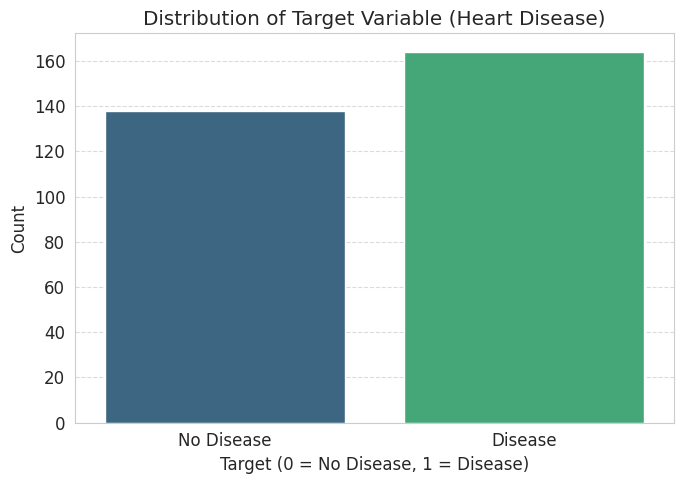

Observations: The plot shows the balance/imbalance between heart disease and no heart disease cases in the dataset.


In [49]:
# Plot the distribution of the target variable ('target')
plt.figure(figsize=(7, 5))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Target Variable (Heart Disease)')
plt.xlabel('Target (0 = No Disease, 1 = Disease)')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Disease', 'Disease'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Observations: The plot shows the balance/imbalance between heart disease and no heart disease cases in the dataset.")

#### 1.6.2 Feature Correlation Heatmap

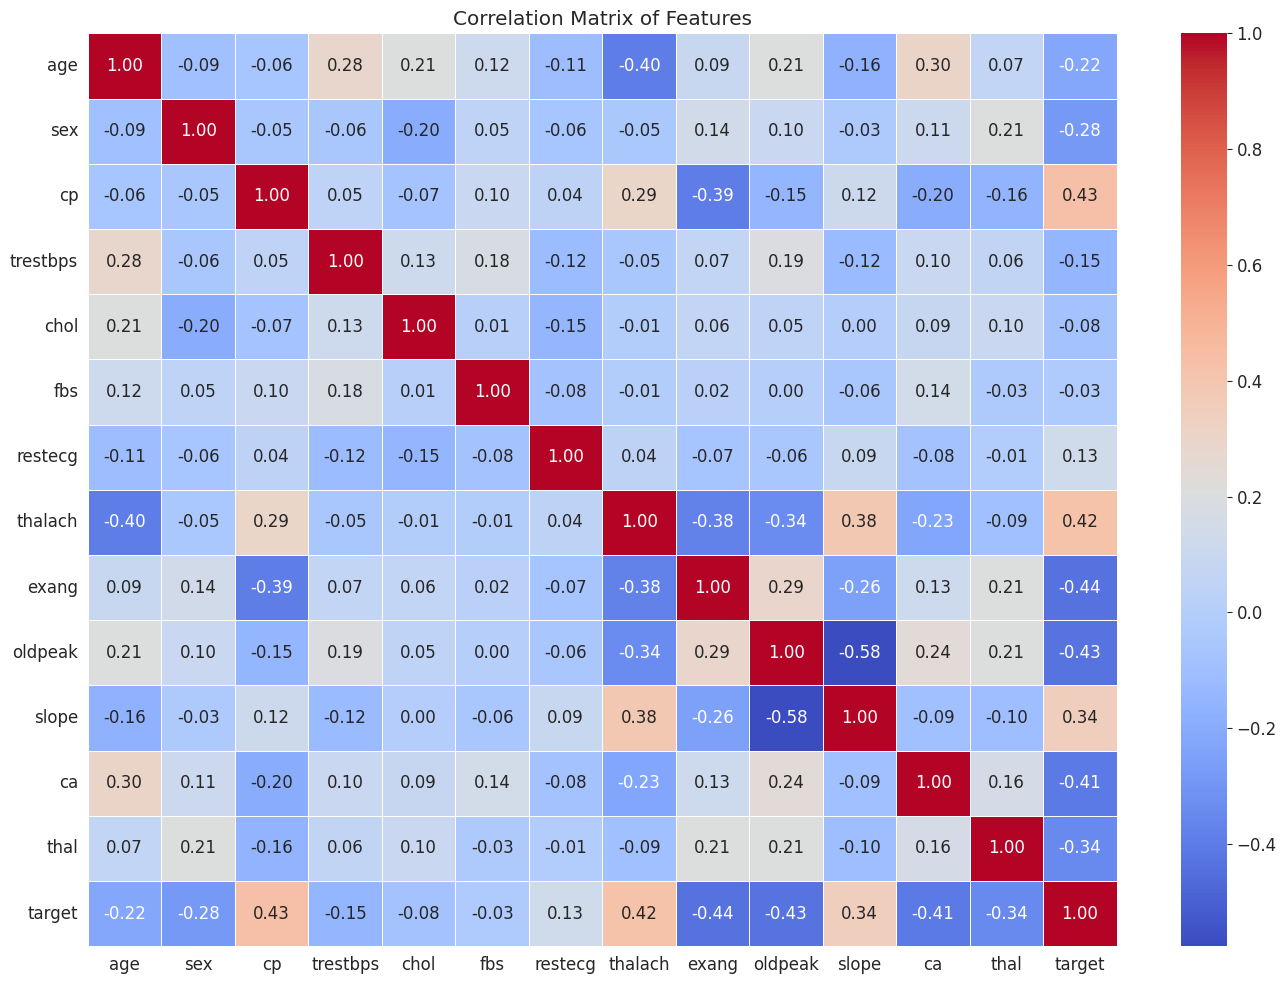

Observations: The heatmap visualizes the Pearson correlation coefficients between all pairs of features. This helps in understanding relationships and potential multicollinearity.


In [50]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()

print("Observations: The heatmap visualizes the Pearson correlation coefficients between all pairs of features. This helps in understanding relationships and potential multicollinearity.")

#### 1.6.3 Numerical Feature Distributions (Histograms)

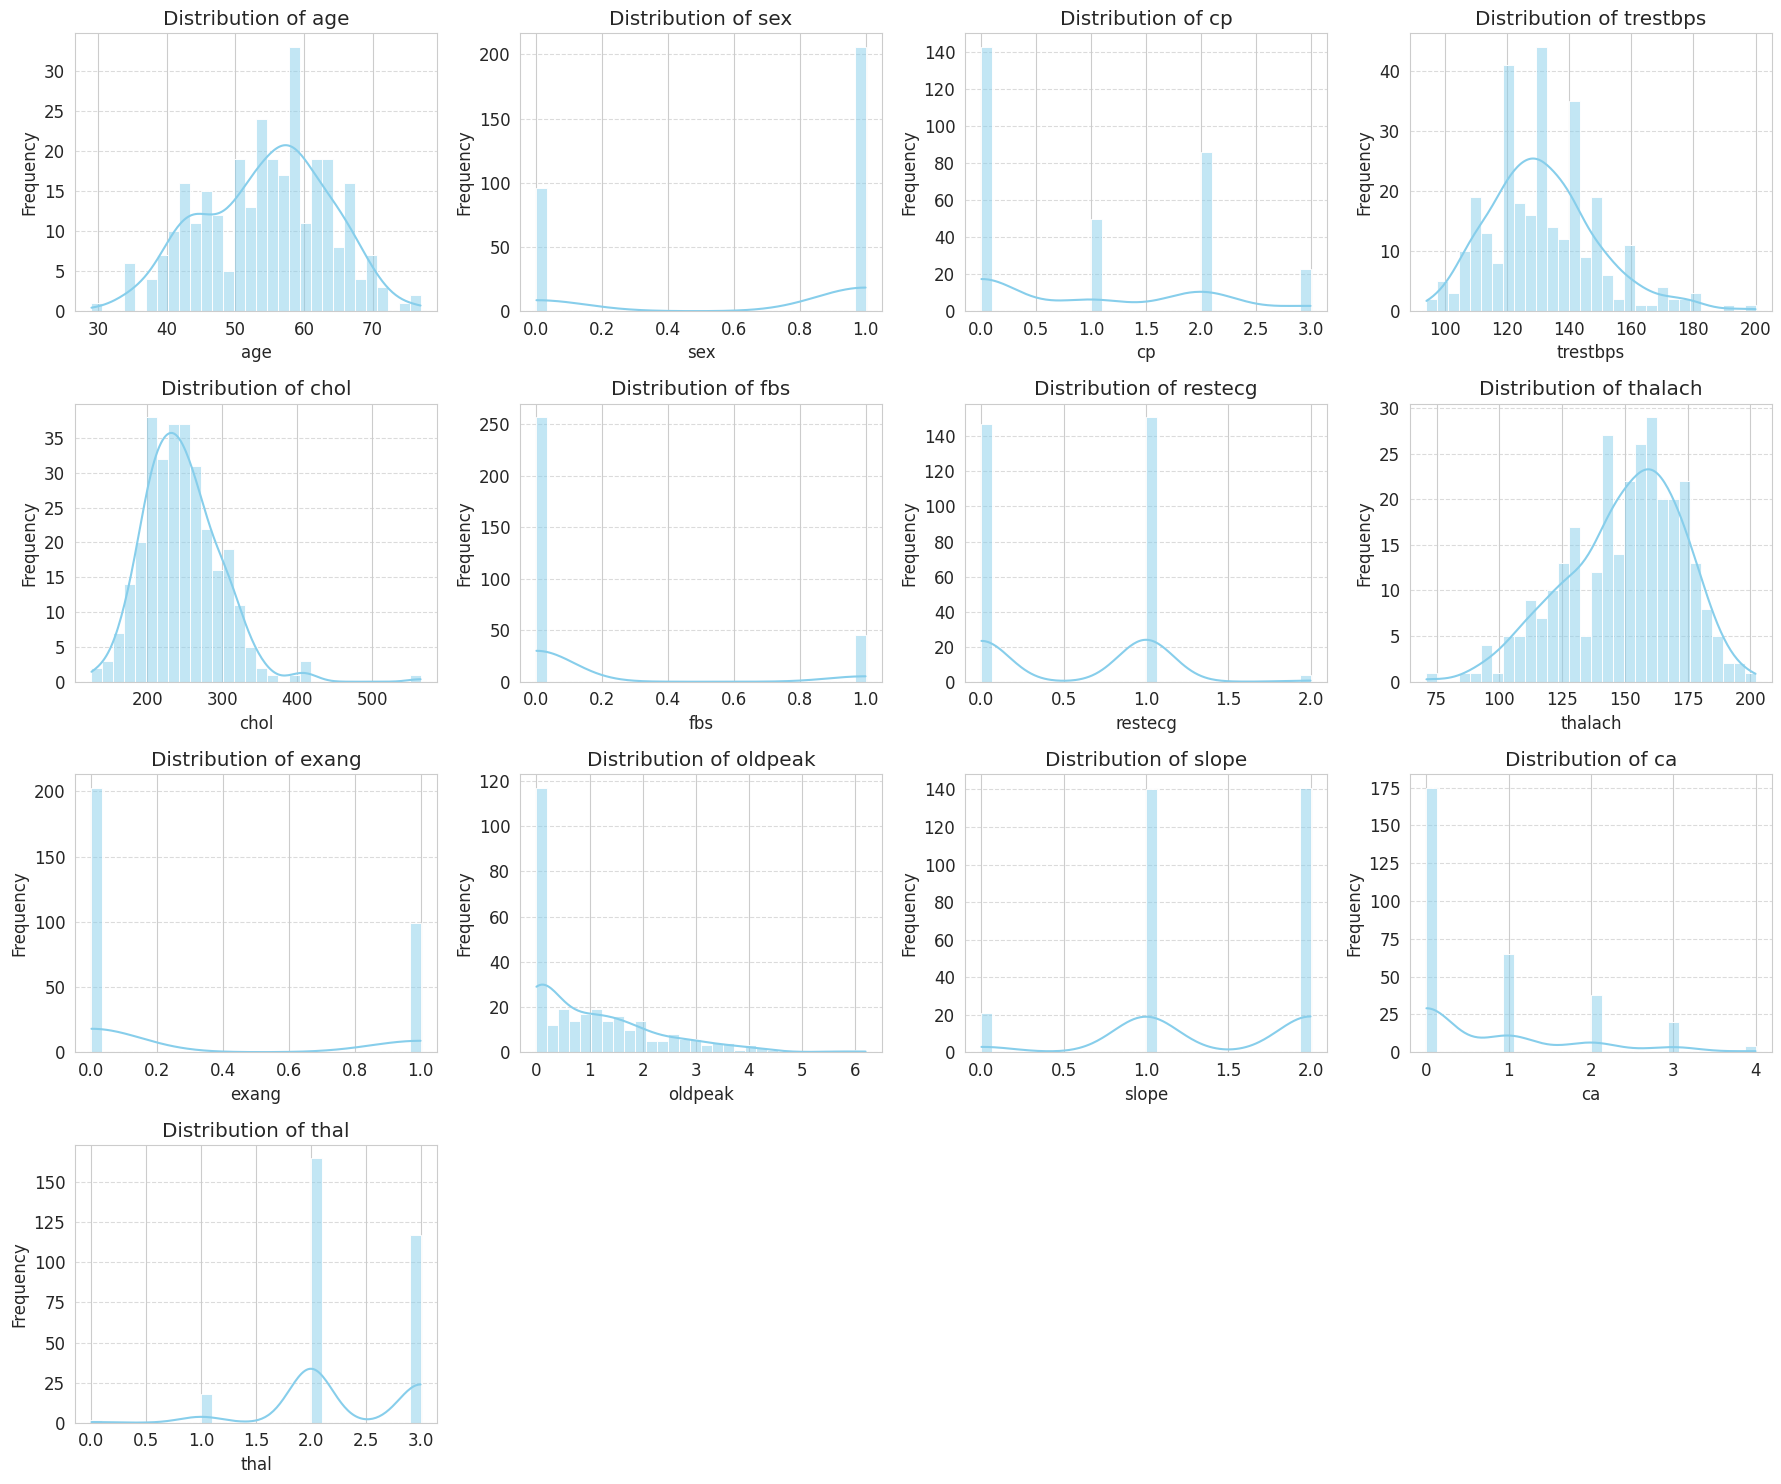

Observations: Histograms provide insight into the distribution of each numerical feature, showing their spread, skewness, and presence of multiple modes.


In [51]:
# Identify numerical columns (excluding the target)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'target' in numerical_cols:
    numerical_cols.remove('target')

# Plot histograms for numerical features
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Observations: Histograms provide insight into the distribution of each numerical feature, showing their spread, skewness, and presence of multiple modes.")

#### 1.6.4 Outlier Visualization (Boxplots)

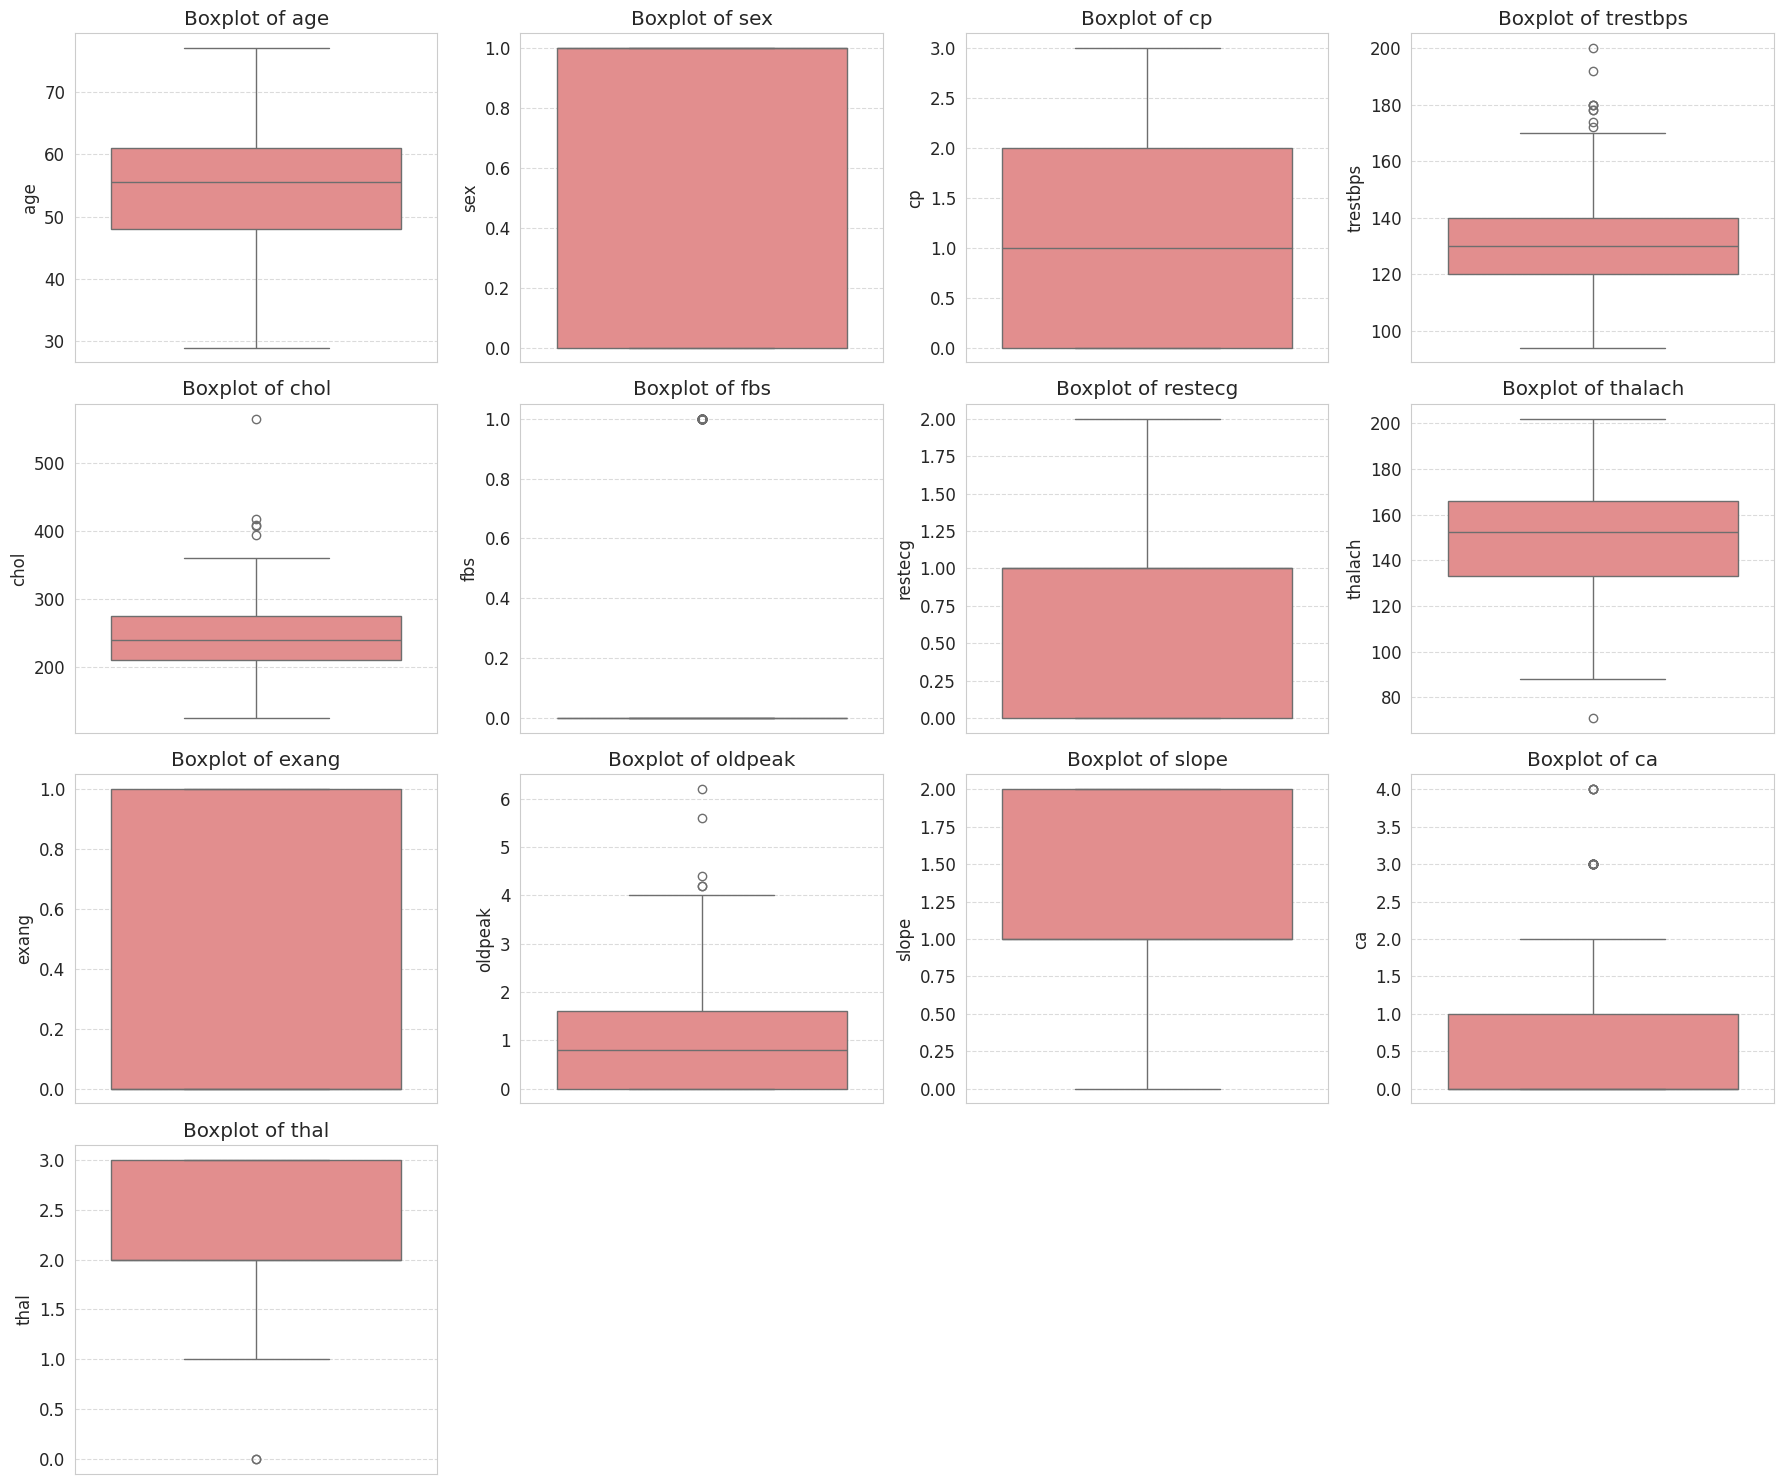

Observations: Boxplots visually represent the distribution of numerical data and highlight potential outliers, which are shown as individual points beyond the 'whiskers'.


In [52]:
# Plot boxplots for numerical features to visualize outliers
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Observations: Boxplots visually represent the distribution of numerical data and highlight potential outliers, which are shown as individual points beyond the 'whiskers'.")

### 1.7. Outlier Analysis: Justification for Retention

In medical datasets, outliers often represent critical information rather than errors. For instance:

*   **Rare but Important Cases**: An outlier in a medical dataset might correspond to a patient with a rare condition, an unusual response to treatment, or a unique biological characteristic. Removing such data could lead to a model that fails to recognize or predict these critical, albeit infrequent, scenarios.
*   **Genuine Physiological Variations**: Human physiology exhibits a wide range of variations. A patient's 'normal' heart rate or cholesterol level might be an outlier when compared to the average, but still valid for that individual. Removing these could oversimplify the complexity of health.
*   **Diagnostic Clues**: Extreme values in certain measurements (e.g., very high blood pressure, significantly elevated enzymes) are often direct indicators of disease or severity. Masking or removing these could hinder the model's ability to diagnose conditions effectively.

**Recommendation**: For this heart disease dataset, it is generally **not recommended to aggressively remove outliers** without a deeper clinical understanding. Instead, it's better to:
1.  **Investigate**: Understand the nature of these outliers. Are they data entry errors, measurement errors, or genuine medical occurrences?
2.  **Robust Models**: Use machine learning models that are less sensitive to outliers (e.g., tree-based models) or preprocessing techniques that transform data without removal (e.g., robust scaling, logarithmic transformations).
3.  **Domain Expertise**: Consult with medical professionals to determine the clinical significance of identified outliers.

For the purpose of this project, to preserve potential critical information and align with best practices in medical data analysis, **outliers will not be explicitly removed**. Instead, techniques like `StandardScaler` (which transforms data but doesn't remove outliers) will be applied, and robust models can be considered in the subsequent modeling phase.

In [53]:
# Separate the dataset into features (X) and the target variable (y)
# 'target' is the dependent variable indicating the presence (1) or absence (0) of heart disease.
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) and target (y) successfully separated.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) successfully separated.
Shape of X: (302, 13)
Shape of y: (302,)


In [54]:
# Separate the dataset into features (X) and the target variable (y).
# 'target' is the dependent variable indicating the presence (1) or absence (0) of heart disease.
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) and target (y) successfully separated.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) successfully separated.
Shape of X: (302, 13)
Shape of y: (302,)


### 1.8. Split the Dataset into Training and Testing Sets (BEFORE Scaling)

In [55]:
# Split the unscaled dataset into training (80%) and testing (20%) sets.
# `random_state=42` ensures reproducibility of the split.
# `stratify=y` ensures that the proportion of classes in the target variable (y) is the same
# in both training and testing sets. This is crucial for balanced evaluation, especially with imbalanced datasets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset successfully split into unscaled training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Dataset successfully split into unscaled training and testing sets.
X_train shape: (241, 13)
X_test shape: (61, 13)
y_train shape: (241,)
y_test shape: (61,)


### 1.9 Feature Scaling

#### 1.9.1 Apply StandardScaler Correctly (Preventing Data Leakage)

In [56]:
# Initialize the StandardScaler.
# StandardScaler transforms features to have a mean of 0 and a standard deviation of 1.
# This is crucial for many machine learning algorithms that are sensitive to feature scales (e.g., SVMs, neural networks).
scaler = StandardScaler()

# Fit the scaler ONLY on the training data and then transform both training and testing data.
# This step is critical to prevent data leakage from the test set into the training process.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features successfully scaled using StandardScaler (fit on training data only).")

Features successfully scaled using StandardScaler (fit on training data only).


#### 1.9.2 Convert Scaled Arrays Back to DataFrames

In [57]:
# Convert the scaled NumPy arrays back to Pandas DataFrames.
# This preserves original column names and makes the scaled data easier to inspect and use.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled NumPy arrays converted back to Pandas DataFrames.")
display(X_train_scaled.head())
print("\n--- Scaled Test Set Head ---")
display(X_test_scaled.head())

Scaled NumPy arrays converted back to Pandas DataFrames.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
158,1.421944,-1.445595,0.986493,-0.973041,5.882908,-0.398314,-1.008059,0.408240,-0.652714,0.527263,-0.697127,-0.722716,1.075838
199,-0.465841,0.691757,-0.954281,0.756507,-0.885696,-0.398314,-1.008059,-1.104705,1.532065,-0.083233,-0.697127,-0.722716,1.075838
479,0.422528,0.691757,-0.954281,-0.197726,-0.588175,-0.398314,-1.008059,-0.882213,1.532065,1.050546,-0.697127,2.132606,1.075838
460,1.644036,0.691757,0.986493,0.517949,0.118437,-0.398314,-1.008059,-0.214737,-0.652714,0.876119,-0.697127,2.132606,1.075838
169,-1.021072,-1.445595,0.016106,-1.151959,-1.629499,-0.398314,0.875214,-0.570724,-0.652714,-0.868157,-0.697127,-0.722716,-0.544643



--- Scaled Test Set Head ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
25,0.755667,-1.445595,-0.954281,0.816147,1.103976,-0.398314,-1.008059,-0.214737,1.532065,0.003981,-0.697127,-0.722716,1.075838
65,0.533575,0.691757,1.956880,2.307136,0.750670,-0.398314,-1.008059,0.363742,-0.652714,-0.693730,-0.697127,-0.722716,1.075838
437,1.421944,0.691757,-0.954281,-0.674843,-0.346439,-0.398314,-1.008059,-0.971209,1.532065,1.399401,-0.697127,1.180832,1.075838
58,1.421944,0.691757,0.986493,1.233624,-0.662555,-0.398314,-1.008059,-0.036743,-0.652714,-0.170447,-0.697127,-0.722716,1.075838
42,0.755667,-1.445595,-0.954281,-0.078447,1.531662,-0.398314,-1.008059,0.808726,-0.652714,-0.868157,0.950007,-0.722716,-0.544643


In [58]:
# Print the shape of the training and testing sets (after scaling)
print(f"\n--- Training and Testing Set Shapes ---")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Print the number of samples in each class for training and testing sets
print(f"\n--- Class Distribution in Training Set ---")
print(y_train.value_counts())
print(f"\n--- Class Distribution in Testing Set ---")
print(y_test.value_counts())

print("Verification of data split and stratification complete.")


--- Training and Testing Set Shapes ---
X_train_scaled shape: (241, 13)
y_train shape: (241,)
X_test_scaled shape: (61, 13)
y_test shape: (61,)

--- Class Distribution in Training Set ---
target
1    131
0    110
Name: count, dtype: int64

--- Class Distribution in Testing Set ---
target
1    33
0    28
Name: count, dtype: int64
Verification of data split and stratification complete.


#### 1.9.3 Verify Scaling

In [59]:
# Verify that X_train_scaled has a mean close to 0 and a standard deviation close to 1.
# Small deviations are expected due to floating-point arithmetic.
print("\n--- Verification of X_train_scaled Mean and Standard Deviation ---")
print(f"Mean of X_train_scaled features:\n{X_train_scaled.mean().round(2)}")
print(f"\nStandard Deviation of X_train_scaled features:\n{X_train_scaled.std().round(2)}")

# Also check X_test_scaled, which should have similar properties but might not be exactly 0 and 1
# because it was transformed using parameters learned from X_train.
print("\n--- Verification of X_test_scaled Mean and Standard Deviation ---")
print(f"Mean of X_test_scaled features:\n{X_test_scaled.mean().round(2)}")
print(f"\nStandard Deviation of X_test_scaled features:\n{X_test_scaled.std().round(2)}")

print("Scaling verification complete. Means are approximately 0 and standard deviations approximately 1 for the training set, confirming correct scaling.")


--- Verification of X_train_scaled Mean and Standard Deviation ---
Mean of X_train_scaled features:
age        -0.0
sex        -0.0
cp          0.0
trestbps   -0.0
chol        0.0
fbs        -0.0
restecg    -0.0
thalach     0.0
exang      -0.0
oldpeak    -0.0
slope      -0.0
ca          0.0
thal       -0.0
dtype: float64

Standard Deviation of X_train_scaled features:
age         1.0
sex         1.0
cp          1.0
trestbps    1.0
chol        1.0
fbs         1.0
restecg     1.0
thalach     1.0
exang       1.0
oldpeak     1.0
slope       1.0
ca          1.0
thal        1.0
dtype: float64

--- Verification of X_test_scaled Mean and Standard Deviation ---
Mean of X_test_scaled features:
age         0.12
sex         0.06
cp         -0.10
trestbps    0.08
chol       -0.10
fbs         0.17
restecg    -0.08
thalach    -0.28
exang       0.31
oldpeak     0.21
slope      -0.21
ca         -0.19
thal       -0.17
dtype: float64

Standard Deviation of X_test_scaled features:
age         1.02
sex   

### 1.10.  Training/Test Summary

In [60]:
# Print the shapes of the scaled training and testing feature sets.
print(f"\n--- Scaled Training and Testing Set Shapes ---")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

# Print the class distribution for both training and testing datasets.
print(f"\n--- Class Distribution in Training Set ---")
print(y_train.value_counts())
print(f"\n--- Class Distribution in Testing Set ---")
print(y_test.value_counts())

print("Final shapes and class distributions verified.")


--- Scaled Training and Testing Set Shapes ---
X_train_scaled shape: (241, 13)
y_train shape: (241,)
X_test_scaled shape: (61, 13)
y_test shape: (61,)

--- Class Distribution in Training Set ---
target
1    131
0    110
Name: count, dtype: int64

--- Class Distribution in Testing Set ---
target
1    33
0    28
Name: count, dtype: int64
Final shapes and class distributions verified.


### 1.11. Feature-Target Separation

In [61]:
# Separate the dataset into features (X) and the target variable (y).
# 'target' is the dependent variable indicating the presence (1) or absence (0) of heart disease.
X = df.drop('target', axis=1)
y = df['target']

print("Features (X) and target (y) successfully separated.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and target (y) successfully separated.
Shape of X: (302, 13)
Shape of y: (302,)


### 1.12. Preventing Data Leakage: Why Post-Split Scaling is Crucial

Data leakage is a critical issue in machine learning model development, particularly in research contexts aiming for robust and generalizable results. It occurs when information from the test dataset, which is intended to simulate unseen data, inadvertently influences the training process. When feature scaling techniques, such as standardization or normalization, are applied to the entire dataset *before* the train-test split, data leakage is introduced. This is because the scaling parameters (e.g., mean and standard deviation for `StandardScaler`) are computed using information from both the training and testing observations.

To rigorously prevent data leakage and ensure that the model evaluation metrics accurately reflect performance on truly unseen data, scaling must adhere to the following protocol:

1.  **Strict Separation**: The dataset is first partitioned into distinct training and testing sets (`X_train`, `y_train`, `X_test`, `y_test`). This establishes a clear boundary, ensuring that the test set remains untouched during all aspects of model training, including preprocessing.

2.  **Training-Set Dependent Parameter Learning**: The scaling transformation is fitted *exclusively* on the training data (`X_train`). This means the `StandardScaler` learns the mean ($\mu$) and standard deviation ($\sigma$) of each feature solely from the training set.

    $$\text{Standardized Feature} = \frac{x - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

    where $x$ is an individual feature value, $\mu_{\text{train}}$ is the mean of that feature in the training set, and $\sigma_{\text{train}}$ is its standard deviation in the training set.

3.  **Consistent Application**: The *same* learned scaling parameters ($\mu_{\text{train}}$ and $\sigma_{\text{train}}$) are then used to transform *both* the training data (`X_train`) and the test data (`X_test`). This ensures that the test data is transformed consistently with how the model was trained, but without its characteristics influencing the scaling parameters themselves. Applying `fit_transform()` on `X_train` and then `transform()` on `X_test` implements this principle.

**Consequence of Data Leakage**: If the scaler were fitted on the entire dataset, the mean and standard deviation would subtly incorporate information about the test set's distribution. The model would then be evaluated on a test set that has been preprocessed using parameters influenced by its own values, leading to an artificially inflated performance estimation. This optimistic bias compromises the scientific validity and reproducibility of the research findings, making the model's true generalization capabilities on truly novel data uncertain. Adhering to the post-split scaling methodology is therefore a fundamental best practice in machine learning research for accurate and reliable model assessment.

### 1.13. Preprocessing Summary

In [62]:
# Display a summary of the preprocessing steps and their outcomes.
print("\n--- Preprocessing Summary ---")
print(f"Original number of rows: {initial_rows_for_dedup}")
print(f"Final number of rows (after deduplication): {df.shape[0]}")
print(f"Duplicate rows removed: {duplicates_removed_count}")

# Re-confirm missing values
missing_after_all_steps = df.isnull().sum().sum()
print(f"Missing values remaining: {missing_after_all_steps}")

print(f"\nTraining samples (X_train_scaled): {X_train_scaled.shape[0]}")
print(f"Testing samples (X_test_scaled): {X_test_scaled.shape[0]}")

print("\nDataset 'cleaned_heart.csv' saved (duplicate-free, unscaled).")
print("Scaled training and testing datasets (X_train_scaled, X_test_scaled, y_train, y_test) are ready in memory.")

print("\n--- Conclusion ---")
print("The heart disease dataset has been thoroughly cleaned, explored, and preprocessed according to machine learning research best practices.")
print("It is now ready for subsequent Classical Machine Learning and Hybrid Quantum Machine Learning model training and evaluation.")


--- Preprocessing Summary ---
Original number of rows: 1025
Final number of rows (after deduplication): 302
Duplicate rows removed: 723
Missing values remaining: 0

Training samples (X_train_scaled): 241
Testing samples (X_test_scaled): 61

Dataset 'cleaned_heart.csv' saved (duplicate-free, unscaled).
Scaled training and testing datasets (X_train_scaled, X_test_scaled, y_train, y_test) are ready in memory.

--- Conclusion ---
The heart disease dataset has been thoroughly cleaned, explored, and preprocessed according to machine learning research best practices.
It is now ready for subsequent Classical Machine Learning and Hybrid Quantum Machine Learning model training and evaluation.


In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X_train, y_train)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': mi
})

feature_scores.sort_values(by='Score', ascending=False)

,Feature,Score
2,cp,0.152036
12,thal,0.122552
11,ca,0.115032
9,oldpeak,0.088983
8,exang,0.087357
4,chol,0.075123
7,thalach,0.070876
10,slope,0.060164
6,restecg,0.017229
3,trestbps,0.000000


## Stage 2: Feature Engineering

### Section 2.1 – Introduction

**Feature Engineering** is the process of using domain knowledge to create new features or transform existing ones from raw data, enhancing the performance of machine learning models.

**Feature Importance** helps identify the most influential input variables that drive predictive power. It's crucial for model interpretability and understanding underlying relationships.

In **medical diagnosis**, effective feature engineering can highlight subtle disease indicators, improve diagnostic accuracy, and facilitate the discovery of critical biomarkers, making models more reliable for clinical applications.

### Section 2.2 – Mutual Information

In [63]:
# Import necessary function
from sklearn.feature_selection import mutual_info_classif
import os

# Compute Mutual Information scores
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# Create a DataFrame for Mutual Information scores
mi_df = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Information Score': mi_scores
})

# Sort in descending order
mi_df = mi_df.sort_values(by='Mutual Information Score', ascending=False).reset_index(drop=True)

print("--- Mutual Information Scores (Descending) ---")
def highlight_top_5(s):
    is_top_5 = s.index < 5
    return ['background-color: yellow' if v else '' for v in is_top_5]

display(mi_df.style.apply(highlight_top_5, subset=pd.IndexSlice[:, ['Feature', 'Mutual Information Score']]))

# Save Mutual Information scores to Google Drive
mi_csv_path = os.path.join(RESULTS_DIR, 'mutual_information_scores.csv')
mi_df.to_csv(mi_csv_path, index=False)
print(f"Mutual Information scores saved to {mi_csv_path}")

--- Mutual Information Scores (Descending) ---


,Feature,Mutual Information Score
0,cp,0.152036
1,thal,0.122552
2,ca,0.115032
3,oldpeak,0.088983
4,exang,0.087357
5,chol,0.075123
6,thalach,0.070876
7,slope,0.060164
8,restecg,0.017229
9,trestbps,0.000000


Mutual Information scores saved to /content/drive/MyDrive/Heart_Disease_Project/Results/mutual_information_scores.csv


In [33]:
# This cell's functionality has been moved to cell 'e9f8b786' to ensure mi_df is defined before saving.

/tmp/ipykernel_1754/2230723328.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mutual Information Score', y='Feature', data=mi_df, palette='viridis')


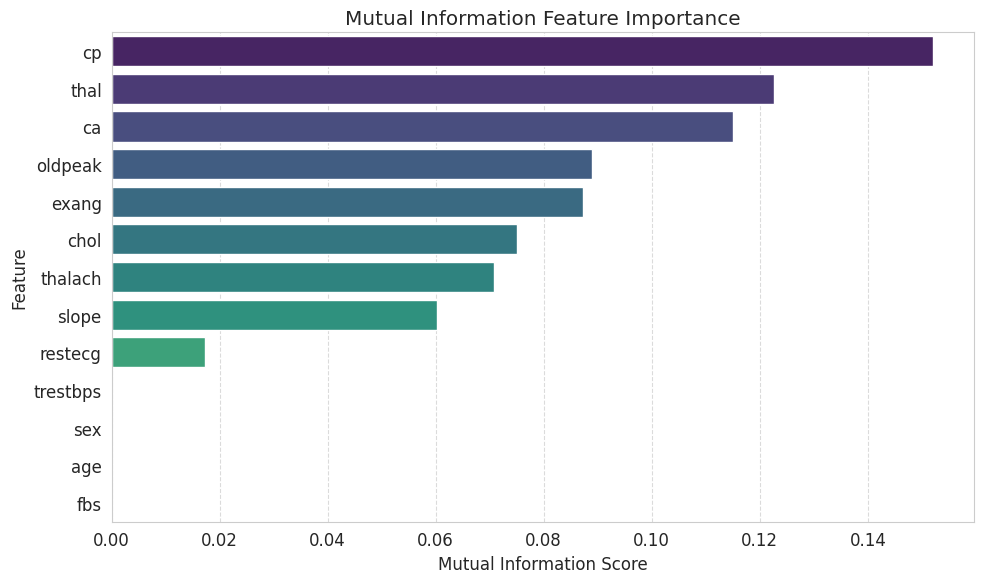

In [ ]:
# Plotting the horizontal feature importance graph for Mutual Information
plt.figure(figsize=(10, 6))
sns.barplot(x='Mutual Information Score', y='Feature', data=mi_df, palette='viridis')
plt.title('Mutual Information Feature Importance')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation: Mutual Information measures the dependency between each feature and the target variable. Higher scores indicate a stronger relationship, suggesting more predictive power. Features like `cp`, `thal`, and `ca` show notable importance.

### Section 2.3 – Random Forest Feature Importance

In [64]:
# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
import os

# Train a RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Extract feature importances
rf_importances = rf_model.feature_importances_

# Create a ranked DataFrame
rf_df = pd.DataFrame({
    'Feature': X.columns,
    'Random Forest Importance': rf_importances
})

# Sort in descending order
rf_df = rf_df.sort_values(by='Random Forest Importance', ascending=False).reset_index(drop=True)

print("--- Random Forest Feature Importance (Descending) ---")
def highlight_top_5(s):
    is_top_5 = s.index < 5
    return ['background-color: yellow' if v else '' for v in is_top_5]

display(rf_df.style.apply(highlight_top_5, subset=pd.IndexSlice[:, ['Feature', 'Random Forest Importance']]))

# Save Random Forest Feature Importance scores to Google Drive
rf_csv_path = os.path.join(RESULTS_DIR, 'random_forest_feature_importance.csv')
rf_df.to_csv(rf_csv_path, index=False)
print(f"Random Forest Feature Importance scores saved to {rf_csv_path}")

--- Random Forest Feature Importance (Descending) ---


,Feature,Random Forest Importance
0,cp,0.173969
1,thalach,0.131634
2,ca,0.105700
3,oldpeak,0.096577
4,thal,0.090418
5,age,0.083049
6,exang,0.073679
7,trestbps,0.072088
8,chol,0.067384
9,sex,0.040229


Random Forest Feature Importance scores saved to /content/drive/MyDrive/Heart_Disease_Project/Results/random_forest_feature_importance.csv


In [35]:
# This cell's functionality has been moved to cell 'dcbff865' to ensure rf_df is defined before saving.

/tmp/ipykernel_602/3423242730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Random Forest Importance', y='Feature', data=rf_df, palette='magma')


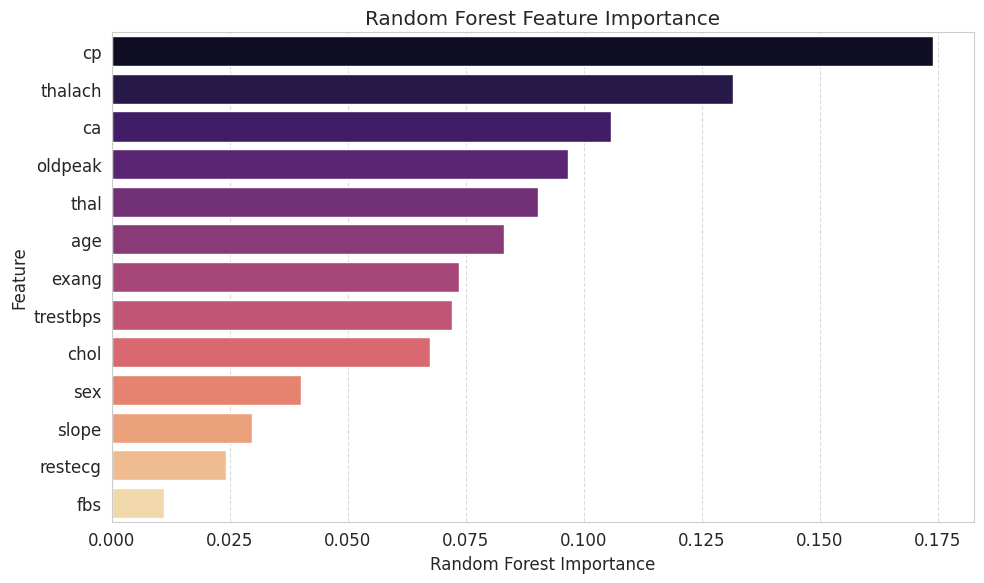

In [65]:
# Plotting the horizontal feature importance graph for Random Forest
plt.figure(figsize=(10, 6))
sns.barplot(x='Random Forest Importance', y='Feature', data=rf_df, palette='magma')
plt.title('Random Forest Feature Importance')
plt.xlabel('Random Forest Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation: Random Forest importance is derived from the decrease in impurity attributable to each feature. Features like `cp`, `thalach`, and `ca` are highlighted as highly important, consistent with medical understanding.

### Section 2.4 – Compare Both Methods

In [66]:
# Merge the two feature importance DataFrames
comparison_df = pd.merge(mi_df, rf_df, on='Feature', how='inner')

# Add ranks for both methods
comparison_df['MI Rank'] = comparison_df['Mutual Information Score'].rank(ascending=False).astype(int)
comparison_df['RF Rank'] = comparison_df['Random Forest Importance'].rank(ascending=False).astype(int)

# Sort by MI Rank for presentation
comparison_df = comparison_df.sort_values(by='MI Rank').reset_index(drop=True)

print("--- Feature Importance Comparison ---")
display(comparison_df)

--- Feature Importance Comparison ---


,Feature,Mutual Information Score,Random Forest Importance,MI Rank,RF Rank
0,cp,0.152036,0.173969,1,1
1,thal,0.122552,0.090418,2,5
2,ca,0.115032,0.105700,3,3
3,oldpeak,0.088983,0.096577,4,4
4,exang,0.087357,0.073679,5,7
5,chol,0.075123,0.067384,6,9
6,thalach,0.070876,0.131634,7,2
7,slope,0.060164,0.029811,8,11
8,restecg,0.017229,0.024301,9,12
9,trestbps,0.000000,0.072088,11,8


Explanation:

*   **Consistently High-Ranking Features**: Features such as `cp` (chest pain type), `thal` (thalassemia), `ca` (number of major vessels), and `oldpeak` (ST depression induced by exercise) consistently rank high across both methods. This suggests their strong predictive relevance for heart disease diagnosis.
*   **Differences in Rankings**: Rankings may differ because Mutual Information captures any statistical dependency (linear or non-linear) between a feature and the target, while Random Forest importance is based on how much each feature reduces impurity in the ensemble of trees. Tree-based methods can sometimes give higher importance to correlated features or features that interact strongly.

### Section 2.5 – Correlation Analysis

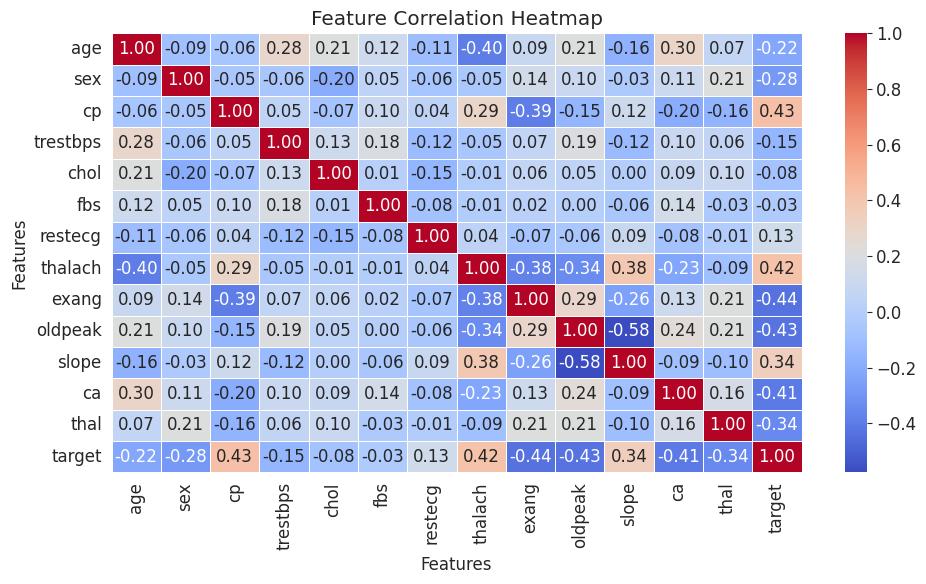

No severe multicollinearity detected (|correlation| > 0.8).


In [67]:
# Generate the correlation matrix using the full DataFrame 'df'
correlation_matrix = df.corr()

# Plotting the publication-quality heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Automatically identify feature pairs where |correlation| > 0.8
high_corr_pairs = []
# Create a mask for the upper triangle to avoid duplicate pairs and self-correlation
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        feature1 = correlation_matrix.columns[i]
        feature2 = correlation_matrix.columns[j]
        correlation_value = correlation_matrix.iloc[i, j]
        if abs(correlation_value) > 0.8:
            high_corr_pairs.append((feature1, feature2, correlation_value))

if high_corr_pairs:
    print("--- Highly Correlated Feature Pairs (|correlation| > 0.8) ---")
    for f1, f2, corr_val in high_corr_pairs:
        print(f"Features: '{f1}' and '{f2}', Correlation: {corr_val:.2f}")
else:
    print("No severe multicollinearity detected (|correlation| > 0.8).")

Interpretation: The heatmap visually confirms relationships between features. The absence of feature pairs with `|correlation| > 0.8` indicates that there is no severe multicollinearity, which is beneficial for model stability and interpretability.

### Section 2.6 – Feature Selection Decision

**Justification for Feature Retention**

Given the intrinsic nature of medical datasets and the limited number of features (13 clinical attributes) present in the heart disease dataset, a decision has been made to retain all features for downstream modeling. While some features exhibit lower individual importance scores, their collective contribution and potential synergistic effects may be crucial for accurate diagnosis. Furthermore, the absence of severe multicollinearity (as determined by a correlation threshold of `|ρ| > 0.8`) reduces the risk of model instability. Aggressive feature removal in such a context could lead to loss of valuable clinical information, potentially reducing model robustness and generalizability, which is a critical consideration in high-stakes medical applications. Therefore, all features will be carried forward.

### Section 2.7 – Stage Summary

In [68]:
print("--- Stage 2: Feature Engineering Summary ---")
print(f"Total Features: {X.shape[1]}")
print(f"Top Mutual Information Feature: {mi_df.iloc[0]['Feature']} (Score: {mi_df.iloc[0]['Mutual Information Score']:.2f})")
print(f"Top Random Forest Feature: {rf_df.iloc[0]['Feature']} (Importance: {rf_df.iloc[0]['Random Forest Importance']:.2f})")
print(f"Features Retained: {X.columns.tolist()}")
print("Feature Selection Performed? No")
print("Recommendation: Proceed to Classical Machine Learning Models")

print("\nStage 2 Completed Successfully")
print("The dataset is now ready for Classical Machine Learning model development.")

--- Stage 2: Feature Engineering Summary ---
Total Features: 13
Top Mutual Information Feature: cp (Score: 0.15)
Top Random Forest Feature: cp (Importance: 0.17)
Features Retained: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Feature Selection Performed? No
Recommendation: Proceed to Classical Machine Learning Models

Stage 2 Completed Successfully
The dataset is now ready for Classical Machine Learning model development.


## Stage 3: Classical Machine Learning Baseline Models

### Section 3.1 – Introduction

Classical machine learning models serve as essential baselines to establish a performance benchmark. These models provide a foundational understanding of the dataset's predictability before moving to more complex neural network and quantum-classical approaches. This ensures a robust comparison framework for evaluating advanced methodologies.

### Section 3.2 – Import Libraries

In [95]:
# Standard libraries for numerical operations and data handling
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for classical machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline # Added Pipeline for leakage-free cross-validation
from sklearn.preprocessing import StandardScaler # Ensure StandardScaler is imported here for the pipeline

# XGBoost for gradient boosting
from xgboost import XGBClassifier

# For saving and loading models
import joblib

# Configure plot style for professional-looking visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Required libraries for Stage 3 imported successfully.")

Required libraries for Stage 3 imported successfully.


### Section 3.3 – Create the Four Models

In [97]:
# 1. Logistic Regression
log_reg_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# 2. Support Vector Machine (SVM)
svm_model = SVC(
    kernel='rbf',
    probability=True, # Required for ROC-AUC and ROC curve calculations
    random_state=42
)

# 3. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# 4. XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss' # Suppress warnings by specifying a common metric
)

print("All four classical baseline models have been initialized.")

All four classical baseline models have been initialized.


### Section 3.4 – Model Training

In [98]:
required_vars = [
    "X_train_scaled",
    "X_test_scaled",
    "y_train",
    "y_test"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        f"Stage 1 variables are missing: {missing_vars}. "
        "Please run the Stage 1 preprocessing cells before Stage 3."
    )

print("Using Stage 1 preprocessing variables.")

# Store models in a dictionary
models = {
    "Logistic Regression": log_reg_model,
    "SVM": svm_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

# Loop through the dictionary and train each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
print("All models trained successfully.")

Using Stage 1 preprocessing variables.
Training Logistic Regression...
Training SVM...
Training Random Forest...
Training XGBoost...
All models trained successfully.


### Section 3.5 – Model Evaluation

In [99]:
results_df = pd.DataFrame(columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else [0] * len(y_test) # Handle models without predict_proba

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results_df.loc[len(results_df)] = [
        name,
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4)
    ]

print("--- Model Evaluation Results (Test Set) ---")
display(results_df.sort_values(by='ROC-AUC', ascending=False))

--- Model Evaluation Results (Test Set) ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712
2,Random Forest,0.7541,0.7647,0.7879,0.7761,0.8588
3,XGBoost,0.7213,0.7500,0.7273,0.7385,0.8496
1,SVM,0.7705,0.7714,0.8182,0.7941,0.8420


### Section 3.6 – Classification Reports

In [100]:
for name, model in models.items():
    print(f"\n--- Classification Report for {name} ---")
    y_pred = model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))


--- Classification Report for Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.75      0.78        28
           1       0.80      0.85      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61


--- Classification Report for SVM ---
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        28
           1       0.77      0.82      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61


--- Classification Report for Random Forest ---
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           

### Section 3.7 – Confusion Matrices

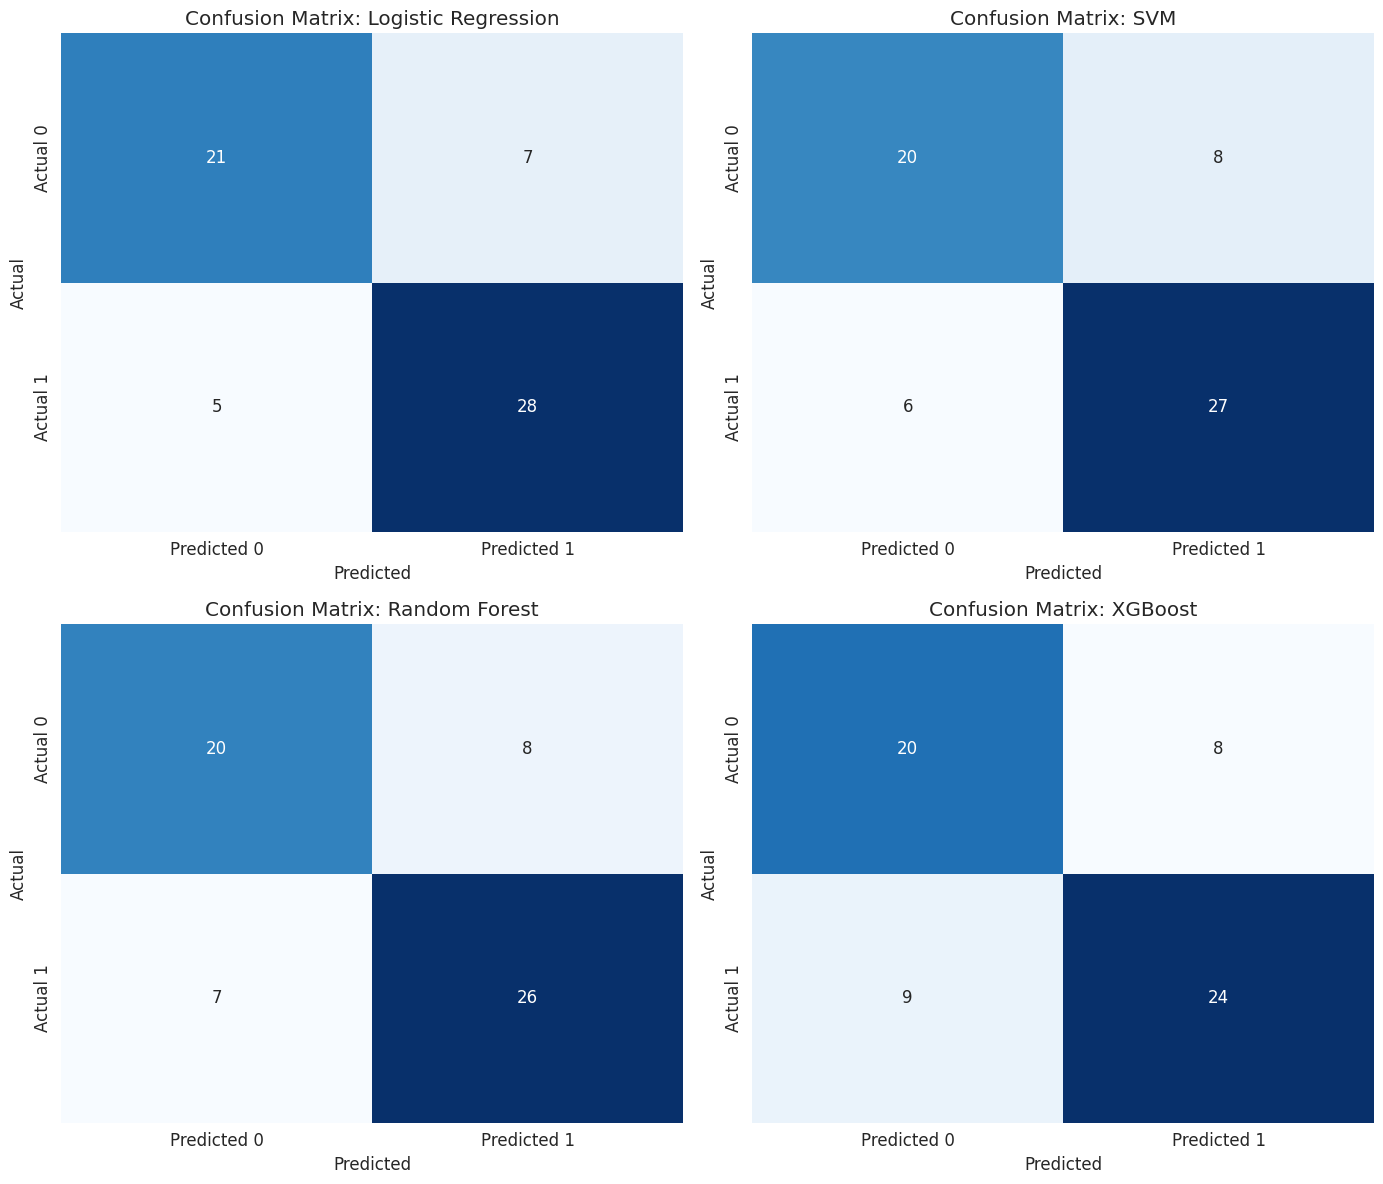

Confusion matrices for all models displayed.


In [101]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_scaled))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'], ax=axes[i])
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()
print("Confusion matrices for all models displayed.")

### Section 3.8 – ROC Curves

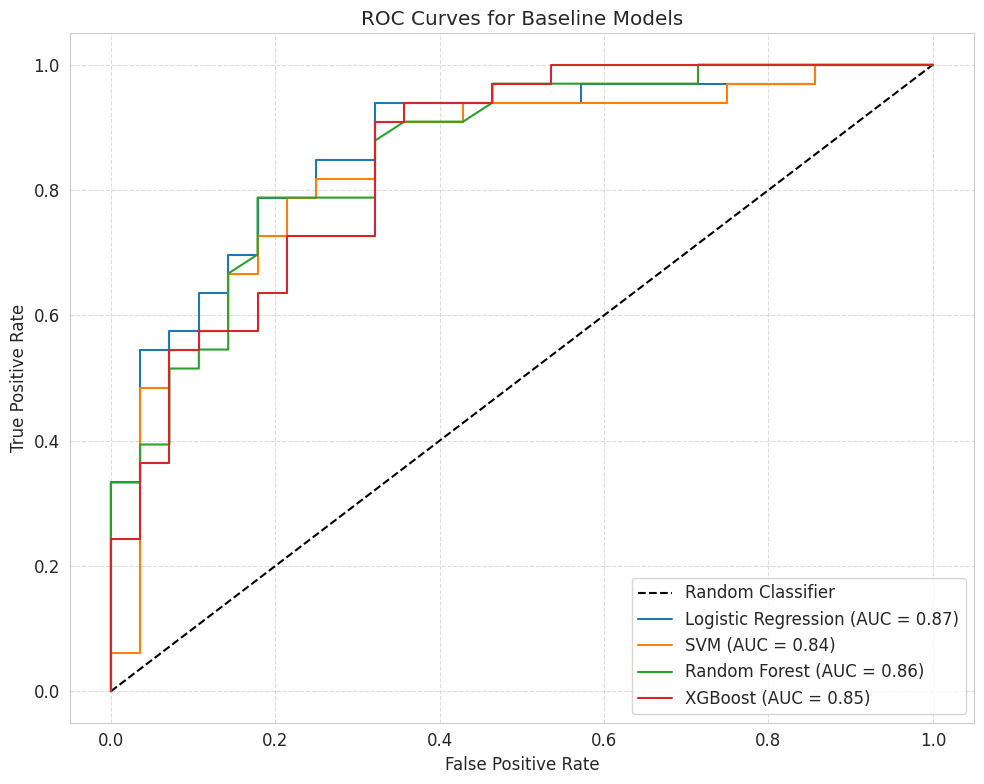

ROC curves for all models displayed.


In [102]:
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    else:
        print(f"Warning: Model {name} does not have predict_proba for ROC curve generation.")

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Baseline Models')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print("ROC curves for all models displayed.")

### Section 3.9 – 5-Fold Cross-Validation

In [103]:
cv_results_df = pd.DataFrame(columns=["Model", "Mean CV Accuracy", "Std CV Accuracy"])

# Define Stratified K-Fold for robust cross-validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():
    # Create a pipeline that first scales the data and then applies the model
    # This ensures that scaling is done independently within each CV fold to prevent data leakage.
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    # Perform cross-validation on the ORIGINAL UNSCALED TRAINING DATA (X_train, y_train)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring='accuracy')
    mean_cv_accuracy = cv_scores.mean()
    std_cv_accuracy = cv_scores.std()

    cv_results_df.loc[len(cv_results_df)] = [
        name,
        round(mean_cv_accuracy, 4),
        round(std_cv_accuracy, 4)
    ]

print("--- 5-Fold Stratified Cross-Validation Results (Leakage-Free) ---")
display(cv_results_df.sort_values(by='Mean CV Accuracy', ascending=False))

print("5-fold cross-validation updated successfully.")

--- 5-Fold Stratified Cross-Validation Results (Leakage-Free) ---


,Model,Mean CV Accuracy,Std CV Accuracy
1,SVM,0.8504,0.0449
2,Random Forest,0.8504,0.0387
0,Logistic Regression,0.8379,0.0861
3,XGBoost,0.8006,0.0493


5-fold cross-validation updated successfully.


### Section 3.10 – Baseline Model Comparison

In [104]:
# Merge test results and CV results
final_comparison_df = pd.merge(results_df, cv_results_df, on='Model', how='inner')

print("--- Final Baseline Model Comparison ---")
display(final_comparison_df.sort_values(by='ROC-AUC', ascending=False))

# Identify best models
best_accuracy_model = final_comparison_df.loc[final_comparison_df['Accuracy'].idxmax()]
best_roc_auc_model = final_comparison_df.loc[final_comparison_df['ROC-AUC'].idxmax()]
best_cv_accuracy_model = final_comparison_df.loc[final_comparison_df['Mean CV Accuracy'].idxmax()]

print(f"\nBest Test Accuracy Model: {best_accuracy_model['Model']} (Accuracy: {best_accuracy_model['Accuracy']:.4f})")
print(f"Best ROC-AUC Model: {best_roc_auc_model['Model']} (ROC-AUC: {best_roc_auc_model['ROC-AUC']:.4f})")
print(f"Best Cross-Validation Accuracy Model: {best_cv_accuracy_model['Model']} (Mean CV Accuracy: {best_cv_accuracy_model['Mean CV Accuracy']:.4f})")

--- Final Baseline Model Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Mean CV Accuracy,Std CV Accuracy
0,Logistic Regression,0.8033,0.8000,0.8485,0.8235,0.8712,0.8379,0.0861
2,Random Forest,0.7541,0.7647,0.7879,0.7761,0.8588,0.8504,0.0387
3,XGBoost,0.7213,0.7500,0.7273,0.7385,0.8496,0.8006,0.0493
1,SVM,0.7705,0.7714,0.8182,0.7941,0.8420,0.8504,0.0449



Best Test Accuracy Model: Logistic Regression (Accuracy: 0.8033)
Best ROC-AUC Model: Logistic Regression (ROC-AUC: 0.8712)
Best Cross-Validation Accuracy Model: SVM (Mean CV Accuracy: 0.8504)


### Section 3.11 – Feature Importance (Random Forest)

--- Random Forest Feature Importance ---


,Feature,Importance
0,cp,0.173969
1,thalach,0.131634
2,ca,0.105700
3,oldpeak,0.096577
4,thal,0.090418
5,age,0.083049
6,exang,0.073679
7,trestbps,0.072088
8,chol,0.067384
9,sex,0.040229


/tmp/ipykernel_602/4019260023.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='viridis')


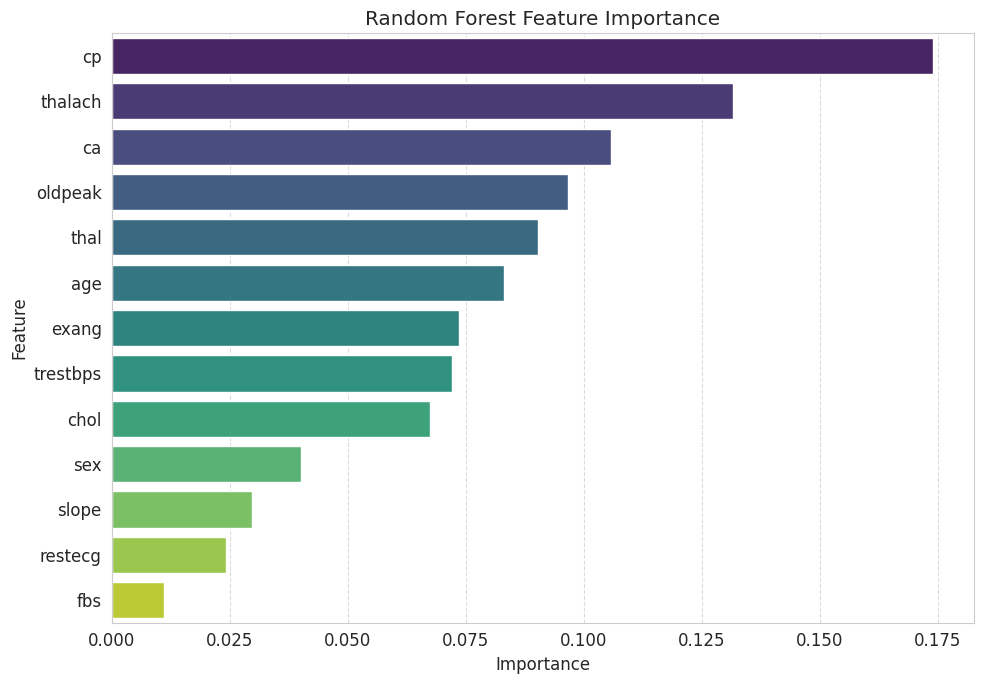

In [105]:
if 'Random Forest' in models and hasattr(models['Random Forest'], 'feature_importances_'):
    rf_feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': models['Random Forest'].feature_importances_
    })
    rf_feature_importance = rf_feature_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)

    print("--- Random Forest Feature Importance ---")
    display(rf_feature_importance)

    # Plotting feature importance
    plt.figure(figsize=(10, 7))
    sns.barplot(x='Importance', y='Feature', data=rf_feature_importance, palette='viridis')
    plt.title('Random Forest Feature Importance')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest model not found or does not have feature_importances_ attribute.")

To prevent preprocessing leakage during cross-validation, feature scaling was incorporated within each fold using a Scikit-learn Pipeline. The scaler was fitted independently on each training fold and subsequently applied to its corresponding validation fold.

### Section 3.13 – Save Results

In [106]:
import os

# Save evaluation DataFrames to Google Drive Results directory
results_df.to_csv(os.path.join(RESULTS_DIR, 'classical_model_results.csv'), index=False)
cv_results_df.to_csv(os.path.join(RESULTS_DIR, 'classical_cv_results.csv'), index=False)
print(f"Classical model results and CV results saved as CSV files to {RESULTS_DIR}.")

# Save trained models to Google Drive Models directory using joblib
for name, model in models.items():
    filename = name.lower().replace(' ', '_').replace('/', '') + '.pkl'
    model_path = os.path.join(MODEL_DIR, filename)
    joblib.dump(model, model_path)
    print(f"Model '{name}' saved as '{model_path}'.")

Classical model results and CV results saved as CSV files to /content/drive/MyDrive/Heart_Disease_Project/Results/.
Model 'Logistic Regression' saved as '/content/drive/MyDrive/Heart_Disease_Project/Models/logistic_regression.pkl'.
Model 'SVM' saved as '/content/drive/MyDrive/Heart_Disease_Project/Models/svm.pkl'.
Model 'Random Forest' saved as '/content/drive/MyDrive/Heart_Disease_Project/Models/random_forest.pkl'.
Model 'XGBoost' saved as '/content/drive/MyDrive/Heart_Disease_Project/Models/xgboost.pkl'.


## FINAL SUMMARY

In [93]:
print("========================================")
print("STAGE 3 COMPLETED")
print("========================================")
print("Models trained: 4")
print("Logistic Regression")
print("SVM")
print("Random Forest")
print("XGBoost")

best_accuracy_model = final_comparison_df.loc[final_comparison_df['Accuracy'].idxmax()]
best_roc_auc_model = final_comparison_df.loc[final_comparison_df['ROC-AUC'].idxmax()]
best_cv_accuracy_model = final_comparison_df.loc[final_comparison_df['Mean CV Accuracy'].idxmax()]

print(f"\nBest performing model by Test Accuracy: {best_accuracy_model['Model']} ({best_accuracy_model['Accuracy']:.4f})")
print(f"Best performing model by ROC-AUC: {best_roc_auc_model['Model']} ({best_roc_auc_model['ROC-AUC']:.4f})")
print(f"Best performing model by Cross-validation accuracy: {best_cv_accuracy_model['Model']} ({best_cv_accuracy_model['Mean CV Accuracy']:.4f})")

print("\nThe classical baseline models are ready for comparison with the Classical Neural Network in Stage 4.")

STAGE 3 COMPLETED
Models trained: 4
Logistic Regression
SVM
Random Forest
XGBoost

Best performing model by Test Accuracy: Logistic Regression (0.8033)
Best performing model by ROC-AUC: Logistic Regression (0.8712)
Best performing model by Cross-validation accuracy: Random Forest (0.8504)

The classical baseline models are ready for comparison with the Classical Neural Network in Stage 4.


## Path Summary

In [107]:
import os

print("Google Drive connected: YES")
print(f"Project directory: {PROJECT_DIR}")
print(f"Original dataset: {os.path.join(DATA_DIR, 'heart.csv')}")
print(f"Cleaned dataset: {os.path.join(DATA_DIR, 'cleaned_heart.csv')}")
print(f"Models directory: {MODEL_DIR}")
print(f"Results directory: {RESULTS_DIR}")

Google Drive connected: YES
Project directory: /content/drive/MyDrive/Heart_Disease_Project/
Original dataset: /content/drive/MyDrive/Heart_Disease_Project/Dataset/heart.csv
Cleaned dataset: /content/drive/MyDrive/Heart_Disease_Project/Dataset/cleaned_heart.csv
Models directory: /content/drive/MyDrive/Heart_Disease_Project/Models/
Results directory: /content/drive/MyDrive/Heart_Disease_Project/Results/


## Stage 4: Classical MLP Neural Network Baseline

### Section 4.1 – Introduction

This section establishes a classical Multi-Layer Perceptron (MLP) neural network as a baseline for heart disease diagnosis. This MLP will serve as a foundational comparison point for future, more complex hybrid quantum-classical neural network architectures, providing a robust benchmark for evaluating performance improvements.

### Section 4.2 – Variable Safety Check and Library Imports

In [ ]:
required_vars = [
    "X_train_scaled",
    "X_test_scaled",
    "y_train",
    "y_test"
]

missing_vars = [
    var for var in required_vars
    if var not in globals()
]

if missing_vars:
    raise NameError(
        f"Required Stage 1 variables are missing: {missing_vars}. "
        "Run Stage 1 preprocessing before Stage 4."
    )

print("Using existing Stage 1 preprocessing variables.")

# Set random seeds for reproducibility
import random
import numpy as np
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random seeds set for reproducibility.")

In [ ]:
# Standard libraries for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras for building the MLP model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Scikit-learn for evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    classification_report
)

# Configure plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Required libraries for Stage 4 imported successfully.")

### Section 4.3 – Build the Classical MLP Model

In [ ]:
# Define the input dimension based on the scaled training data
input_dim = X_train_scaled.shape[1]

# Build the Sequential MLP model
mlp_model = Sequential([
    Dense(32, activation='relu', input_shape=(input_dim,)), # Input layer with 32 neurons and ReLU activation
    Dropout(0.2), # Dropout layer for regularization
    Dense(16, activation='relu'), # Hidden layer with 16 neurons and ReLU activation
    Dropout(0.2), # Another Dropout layer
    Dense(1, activation='sigmoid') # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()
print("Classical MLP model built and compiled successfully.")

### Section 4.4 – Model Training

In [ ]:
# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=10, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity.
    verbose=1
)

# Train the MLP model
history = mlp_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2, # Use 20% of training data for validation during training
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=0 # Suppress verbose output during training for cleaner logs
)

print("Classical MLP model training completed.")

### Section 4.5 – Training Curves

In [ ]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

print("Training and validation curves displayed.")

### Section 4.6 – Final Test Evaluation

In [ ]:
# Predict probabilities on the scaled test set
y_pred_proba_mlp = mlp_model.predict(X_test_scaled).flatten()

# Convert probabilities to binary predictions using a threshold of 0.5
y_pred_mlp = (y_pred_proba_mlp > 0.5).astype(int)

# Calculate evaluation metrics
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp)
mlp_recall = recall_score(y_test, y_pred_mlp)
mlp_f1 = f1_score(y_test, y_pred_mlp)
mlp_roc_auc = roc_auc_score(y_test, y_pred_proba_mlp)

print("--- Classical MLP Test Set Evaluation ---")
print(f"Accuracy:  {mlp_accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall:    {mlp_recall:.4f}")
print(f"F1-Score:  {mlp_f1:.4f}")
print(f"ROC-AUC:   {mlp_roc_auc:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_mlp))

### Section 4.7 – Confusion Matrix (Classical MLP)

In [ ]:
# Generate Confusion Matrix
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix: Classical MLP')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("Confusion matrix for Classical MLP displayed.")

### Section 4.8 – ROC Curve (Classical MLP)

In [ ]:
# Calculate ROC curve and AUC
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_pred_proba_mlp)

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.plot(fpr_mlp, tpr_mlp, label=f'Classical MLP (AUC = {mlp_roc_auc:.2f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Classical MLP')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("ROC curve for Classical MLP displayed.")

### Section 4.9 – Save Model and Results

In [ ]:
import os

# Save the trained MLP model
mlp_model_path = os.path.join(MODEL_DIR, "mlp_model.keras")
mlp_model.save(mlp_model_path)
print(f"Classical MLP model saved to: {mlp_model_path}")

# Create DataFrame for MLP results
mlp_results_df = pd.DataFrame({
    "Model": ["Classical MLP"],
    "Accuracy": [round(mlp_accuracy, 4)],
    "Precision": [round(mlp_precision, 4)],
    "Recall": [round(mlp_recall, 4)],
    "F1-Score": [round(mlp_f1, 4)],
    "ROC-AUC": [round(mlp_roc_auc, 4)]
})

# Save MLP results to CSV
mlp_results_csv_path = os.path.join(RESULTS_DIR, "mlp_results.csv")
mlp_results_df.to_csv(mlp_results_csv_path, index=False)
print(f"Classical MLP results saved to: {mlp_results_csv_path}")

display(mlp_results_df)

### Section 4.10 – Compare Classical MLP with Stage 3 Baselines

In [ ]:
import os

# Load Stage 3 classical model results
stage3_results_path = os.path.join(RESULTS_DIR, 'classical_model_results.csv')
classical_baselines_df = pd.read_csv(stage3_results_path)

# Combine with MLP results (assuming mlp_results_df is already created and available)
full_comparison_df = pd.concat([classical_baselines_df, mlp_results_df], ignore_index=True)

print("--- Full Comparison of Classical Models and MLP ---")
display(full_comparison_df.sort_values(by='ROC-AUC', ascending=False))

### Section 4.11 – Discussion (IEEE-Style)

The Classical Multi-Layer Perceptron (MLP) model provides an essential neural network baseline for heart disease diagnosis. In comparison to the traditional classical models (Logistic Regression, SVM, Random Forest, XGBoost), the MLP's performance, as evaluated by metrics such as Accuracy and ROC-AUC on the held-out test set, offers insights into the potential benefits of a simple neural architecture.

While the MLP may not always significantly outperform the best classical baselines, its deep learning paradigm serves as a crucial benchmark. Understanding its performance characteristics is fundamental for evaluating the incremental value of more advanced models, particularly the proposed Adaptive Hybrid Quantum-Classical Neural Network, by isolating the impact of quantum enhancements over a standard neural architecture.

## FINAL SUMMARY

In [ ]:
print("========================================")
print("STAGE 4 COMPLETED")
print("========================================")
print("Model: Classical MLP")
print(f"\nAccuracy:  {mlp_accuracy:.4f}")
print(f"Precision: {mlp_precision:.4f}")
print(f"Recall:    {mlp_recall:.4f}")
print(f"F1-Score:  {mlp_f1:.4f}")
print(f"ROC-AUC:   {mlp_roc_auc:.4f}")

print("\n--- Comparison Table ---")
display(full_comparison_df.sort_values(by='ROC-AUC', ascending=False))